# HydroMet-ETL: Initial Data Profiling

## DSAI 6226 — Data Engineering and Analytics

### Dataset
NASA POWER Daily Hydrometeorological Data

### Study Area
Selected locations across Tanzania

### Temporal Coverage
2001–2025

### Objective
This notebook performs an initial assessment of the raw/interim hydrometeorological dataset to identify data quality issues before cleaning or transformation.

The profiling focuses on schema and data types, spatial and temporal coverage, completeness, duplicate observations, missing dates, invalid or suspicious values, meteorological consistency, and potential outliers.

**No data cleaning is performed in this notebook.**


## 1. Import Required Libraries

**Purpose:** Load Python libraries used for file handling, tabular data analysis, numerical operations, JSON reporting, and visualization.


In [45]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


## 2. Configure Project Paths

**Purpose:** Locate the project root, input dataset, report directory, and figures directory, and verify that the dataset exists before continuing.


In [46]:
# Robust project-root detection
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd

DATA_PATH = PROJECT_ROOT / 'data' / 'interim' / 'nasa_power_tanzania_daily.csv'
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Dataset:', DATA_PATH)
print('Exists:', DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}. Run the NASA POWER ingestion script first.'
    )


Project root: d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline
Dataset: d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\data\interim\nasa_power_tanzania_daily.csv
Exists: True


## 3. Load the Hydrometeorological Dataset

**Purpose:** Read the NASA POWER interim CSV into a Pandas DataFrame and inspect the first records and dataset dimensions.


In [47]:
df = pd.read_csv(DATA_PATH)

print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]:,}')
display(df.head())


Rows: 73,048
Columns: 12


,date,location,latitude,longitude,T2M,T2M_MIN,T2M_MAX,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,source
0,2001-01-01,Arusha,-3.387,36.683,23.610,16.490,31.040,60.620,0.580,0.880,22.340,NASA_POWER
1,2001-01-02,Arusha,-3.387,36.683,24.040,18.030,30.170,59.560,0.300,1.020,22.210,NASA_POWER
2,2001-01-03,Arusha,-3.387,36.683,24.870,18.500,31.870,58.280,0.950,1.330,22.780,NASA_POWER
3,2001-01-04,Arusha,-3.387,36.683,24.770,18.400,31.850,62.470,1.660,1.420,21.990,NASA_POWER
4,2001-01-05,Arusha,-3.387,36.683,23.070,18.970,28.950,71.450,1.960,1.000,16.190,NASA_POWER


## 4. Summarize Dataset Dimensions and Columns

**Purpose:** Record the number of rows, number of columns, and column names for the initial dataset inventory.


In [48]:
dataset_summary = {
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1]),
    'column_names': df.columns.tolist(),
}

dataset_summary


{'rows': 73048,
 'columns': 12,
 'column_names': ['date',
  'location',
  'latitude',
  'longitude',
  'T2M',
  'T2M_MIN',
  'T2M_MAX',
  'RH2M',
  'PRECTOTCORR',
  'WS2M',
  'ALLSKY_SFC_SW_DWN',
  'source']}

## 5. Inspect the Dataset Schema

**Purpose:** Examine each column's data type, non-null count, missing count, and number of unique values.


In [49]:
schema_df = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'non_null': df.notna().sum().values,
    'null': df.isna().sum().values,
    'unique': df.nunique(dropna=True).values,
})

display(schema_df)


,column,dtype,non_null,null,unique
0,date,str,73048,0,9131
1,location,str,73048,0,8
2,latitude,float64,73048,0,8
3,longitude,float64,73048,0,8
4,T2M,float64,73048,0,1872
5,T2M_MIN,float64,73048,0,2351
6,T2M_MAX,float64,73048,0,1889
7,RH2M,float64,73048,0,5966
8,PRECTOTCORR,float64,73048,0,3522
9,WS2M,float64,73048,0,696


## 6. Parse and Validate the Date Column

**Purpose:** Create a profiling copy of the data, convert the date field to a proper datetime type, and count dates that cannot be parsed.


In [50]:
profile_df = df.copy()
profile_df['date_original'] = profile_df['date']
profile_df['date'] = pd.to_datetime(profile_df['date'], errors='coerce')

invalid_dates = int(profile_df['date'].isna().sum())
print(f'Invalid/unparseable dates: {invalid_dates:,}')


Invalid/unparseable dates: 0


## 7. Assess Temporal Coverage

**Purpose:** Determine the earliest and latest dates and compare temporal coverage across all study locations.


In [51]:
print('Minimum date:', profile_df['date'].min())
print('Maximum date:', profile_df['date'].max())

temporal_coverage = profile_df.groupby('location')['date'].agg(['min', 'max', 'count'])
display(temporal_coverage)


Minimum date: 2001-01-01 00:00:00
Maximum date: 2025-12-31 00:00:00


,min,max,count
location,,,
Arusha,2001-01-01,2025-12-31,9131
Dar_es_Salaam,2001-01-01,2025-12-31,9131
Dodoma,2001-01-01,2025-12-31,9131
Mbeya,2001-01-01,2025-12-31,9131
Morogoro,2001-01-01,2025-12-31,9131
Mwanza,2001-01-01,2025-12-31,9131
Songea,2001-01-01,2025-12-31,9131
Tabora,2001-01-01,2025-12-31,9131


## 8. Assess Spatial Coverage and Coordinate Consistency

**Purpose:** List the study locations and coordinates and check whether any named location is associated with multiple latitude or longitude values.


In [52]:
locations = (
    profile_df[['location', 'latitude', 'longitude']]
    .drop_duplicates()
    .sort_values('location')
)

print('Number of unique locations:', profile_df['location'].nunique())
display(locations)

coordinate_variations = (
    profile_df.groupby('location')
    .agg(
        latitude_count=('latitude', 'nunique'),
        longitude_count=('longitude', 'nunique')
    )
)
display(coordinate_variations)


Number of unique locations: 8


,location,latitude,longitude
0,Arusha,-3.387,36.683
18262,Dar_es_Salaam,-6.792,39.208
9131,Dodoma,-6.163,35.752
36524,Mbeya,-8.909,33.461
27393,Morogoro,-6.824,37.668
45655,Mwanza,-2.516,32.917
54786,Songea,-10.682,35.651
63917,Tabora,-5.016,32.827


,latitude_count,longitude_count
location,,
Arusha,1,1
Dar_es_Salaam,1,1
Dodoma,1,1
Mbeya,1,1
Morogoro,1,1
Mwanza,1,1
Songea,1,1
Tabora,1,1


## 9. Generate Descriptive Statistics for Meteorological Variables

**Purpose:** Verify that expected NASA POWER variables exist and summarize their distributions using count, mean, standard deviation, quartiles, minimum, and maximum.


In [53]:
meteo_columns = [
    'T2M',
    'T2M_MIN',
    'T2M_MAX',
    'RH2M',
    'PRECTOTCORR',
    'WS2M',
    'ALLSKY_SFC_SW_DWN',
]

missing_meteo = [c for c in meteo_columns if c not in profile_df.columns]
if missing_meteo:
    raise KeyError(f'Missing expected meteorological columns: {missing_meteo}')

display(profile_df[meteo_columns].describe().T)


,count,mean,std,min,25%,50%,75%,max
T2M,"73,048.000",22.390,3.393,8.760,20.550,22.690,24.830,30.050
T2M_MIN,"73,048.000",17.700,4.230,1.800,15.010,17.820,20.080,28.010
T2M_MAX,"73,048.000",28.094,3.323,13.190,25.940,28.240,30.310,38.170
RH2M,"73,048.000",70.904,13.030,23.690,61.930,72.910,81.370,96.390
PRECTOTCORR,"73,048.000",3.255,7.948,0.000,0.030,0.500,3.230,269.770
WS2M,"73,048.000",2.610,1.304,0.220,1.590,2.510,3.530,8.400
ALLSKY_SFC_SW_DWN,"73,048.000",20.455,4.341,1.770,17.770,21.110,23.620,29.710


## 10. Assess Ordinary Missing Values

**Purpose:** Calculate missing-value counts and percentages for every column and visualize variables with missing observations.


In [54]:
missing_summary = pd.DataFrame({
    'missing_count': profile_df.isna().sum(),
    'missing_percent': profile_df.isna().mean() * 100
}).sort_values('missing_percent', ascending=False)

display(missing_summary)

missing_plot = missing_summary[missing_summary['missing_count'] > 0]
if not missing_plot.empty:
    missing_plot['missing_percent'].plot(kind='bar', figsize=(10, 5))
    plt.title('Missing Values by Variable')
    plt.ylabel('Missing (%)')
    plt.xlabel('Variable')
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / 'missing_values_by_variable.png', dpi=200)
    plt.show()
else:
    print('No ordinary NaN missing values detected.')


,missing_count,missing_percent
date,0,0.000
location,0,0.000
latitude,0,0.000
longitude,0,0.000
T2M,0,0.000
T2M_MIN,0,0.000
T2M_MAX,0,0.000
RH2M,0,0.000
PRECTOTCORR,0,0.000
WS2M,0,0.000


No ordinary NaN missing values detected.


## 11. Detect Potential Sentinel or Fill Values

**Purpose:** Search meteorological variables for suspicious numeric codes that may represent encoded missing observations rather than valid measurements.


In [55]:
sentinel_candidates = [-9999, -999, -99, 999, 9999]
sentinel_results = {}

for col in meteo_columns:
    counts = {}
    for value in sentinel_candidates:
        n = int((profile_df[col] == value).sum())
        if n > 0:
            counts[str(value)] = n
    sentinel_results[col] = counts

sentinel_results


{'T2M': {},
 'T2M_MIN': {},
 'T2M_MAX': {},
 'RH2M': {},
 'PRECTOTCORR': {},
 'WS2M': {},
 'ALLSKY_SFC_SW_DWN': {}}

## 12. Detect Exact Duplicate Rows

**Purpose:** Count records that are identical across all columns and display examples for investigation.


In [56]:
exact_duplicates = int(profile_df.duplicated().sum())
print(f'Exact duplicate rows: {exact_duplicates:,}')

dup_rows = profile_df[profile_df.duplicated(keep=False)].sort_values(['location', 'date'])
display(dup_rows.head(20))


Exact duplicate rows: 0


,date,location,latitude,longitude,T2M,T2M_MIN,T2M_MAX,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,source,date_original


## 13. Detect Duplicate Location-Date Keys

**Purpose:** Test the logical business key of location plus date to identify multiple observations representing the same place and day.


In [57]:
business_key_duplicates = profile_df.duplicated(
    subset=['location', 'date'], keep=False
)
business_duplicate_count = int(business_key_duplicates.sum())

print(f'Rows involved in duplicate location-date keys: {business_duplicate_count:,}')
display(
    profile_df[business_key_duplicates]
    .sort_values(['location', 'date'])
    .head(30)
)


Rows involved in duplicate location-date keys: 0


,date,location,latitude,longitude,T2M,T2M_MIN,T2M_MAX,RH2M,PRECTOTCORR,WS2M,ALLSKY_SFC_SW_DWN,source,date_original


## 14. Measure Missing Dates by Location

**Purpose:** Compare expected daily dates with observed dates for each location to identify temporal gaps in the time series.


In [58]:
def find_missing_dates(group):
    valid_dates = group['date'].dropna()
    if valid_dates.empty:
        return pd.Series({
            'start_date': pd.NaT,
            'end_date': pd.NaT,
            'expected_days': 0,
            'observed_unique_days': 0,
            'missing_days': 0,
        })

    start = valid_dates.min()
    end = valid_dates.max()
    expected_dates = pd.date_range(start=start, end=end, freq='D')
    actual_dates = pd.DatetimeIndex(valid_dates.unique())
    missing_dates = expected_dates.difference(actual_dates)

    return pd.Series({
        'start_date': start,
        'end_date': end,
        'expected_days': len(expected_dates),
        'observed_unique_days': len(actual_dates),
        'missing_days': len(missing_dates),
    })

date_gap_summary = profile_df.groupby('location').apply(find_missing_dates)
display(date_gap_summary)


,start_date,end_date,expected_days,observed_unique_days,missing_days
location,,,,,
Arusha,2001-01-01,2025-12-31,9131,9131,0
Dar_es_Salaam,2001-01-01,2025-12-31,9131,9131,0
Dodoma,2001-01-01,2025-12-31,9131,9131,0
Mbeya,2001-01-01,2025-12-31,9131,9131,0
Morogoro,2001-01-01,2025-12-31,9131,9131,0
Mwanza,2001-01-01,2025-12-31,9131,9131,0
Songea,2001-01-01,2025-12-31,9131,9131,0
Tabora,2001-01-01,2025-12-31,9131,9131,0


## 15. Identify the Actual Missing Dates

**Purpose:** Store the specific missing calendar dates for every study location so temporal gaps can be investigated later.


In [59]:
missing_dates_by_location = {}

for location, group in profile_df.groupby('location'):
    valid_dates = group['date'].dropna()
    if valid_dates.empty:
        missing_dates_by_location[location] = []
        continue

    expected = pd.date_range(valid_dates.min(), valid_dates.max(), freq='D')
    observed = pd.DatetimeIndex(valid_dates.unique())
    missing = expected.difference(observed)
    missing_dates_by_location[location] = [d.strftime('%Y-%m-%d') for d in missing]

{k: v[:10] for k, v in missing_dates_by_location.items()}


{'Arusha': [],
 'Dar_es_Salaam': [],
 'Dodoma': [],
 'Mbeya': [],
 'Morogoro': [],
 'Mwanza': [],
 'Songea': [],
 'Tabora': []}

## 16. Check Temperature Consistency

**Purpose:** Test whether minimum, mean, and maximum temperature values obey the expected relationship: T2M_MIN ≤ T2M ≤ T2M_MAX.


In [60]:
invalid_temp_order = profile_df[
    (profile_df['T2M_MIN'] > profile_df['T2M']) |
    (profile_df['T2M'] > profile_df['T2M_MAX'])
]

print('Temperature consistency violations:', len(invalid_temp_order))
display(invalid_temp_order[['date', 'location', 'T2M_MIN', 'T2M', 'T2M_MAX']].head(20))


Temperature consistency violations: 0


,date,location,T2M_MIN,T2M,T2M_MAX


## 17. Check Physical and Domain Validity Rules

**Purpose:** Flag invalid relative humidity, negative precipitation, negative wind speed, negative solar radiation, and globally invalid coordinates.


In [61]:
invalid_humidity = profile_df[(profile_df['RH2M'] < 0) | (profile_df['RH2M'] > 100)]
negative_precipitation = profile_df[profile_df['PRECTOTCORR'] < 0]
negative_wind = profile_df[profile_df['WS2M'] < 0]
negative_solar = profile_df[profile_df['ALLSKY_SFC_SW_DWN'] < 0]
invalid_coordinates = profile_df[
    (profile_df['latitude'] < -90) |
    (profile_df['latitude'] > 90) |
    (profile_df['longitude'] < -180) |
    (profile_df['longitude'] > 180)
]

print('Invalid relative humidity records:', len(invalid_humidity))
print('Negative precipitation records:', len(negative_precipitation))
print('Negative wind-speed records:', len(negative_wind))
print('Negative solar-radiation records:', len(negative_solar))
print('Invalid coordinate records:', len(invalid_coordinates))


Invalid relative humidity records: 0
Negative precipitation records: 0
Negative wind-speed records: 0
Negative solar-radiation records: 0
Invalid coordinate records: 0


## 18. Compare Observation Counts Across Locations

**Purpose:** Count daily observations for each location and visualize whether all study locations have comparable record coverage.


location
Arusha           9131
Dar_es_Salaam    9131
Dodoma           9131
Mbeya            9131
Morogoro         9131
Mwanza           9131
Songea           9131
Tabora           9131
dtype: int64

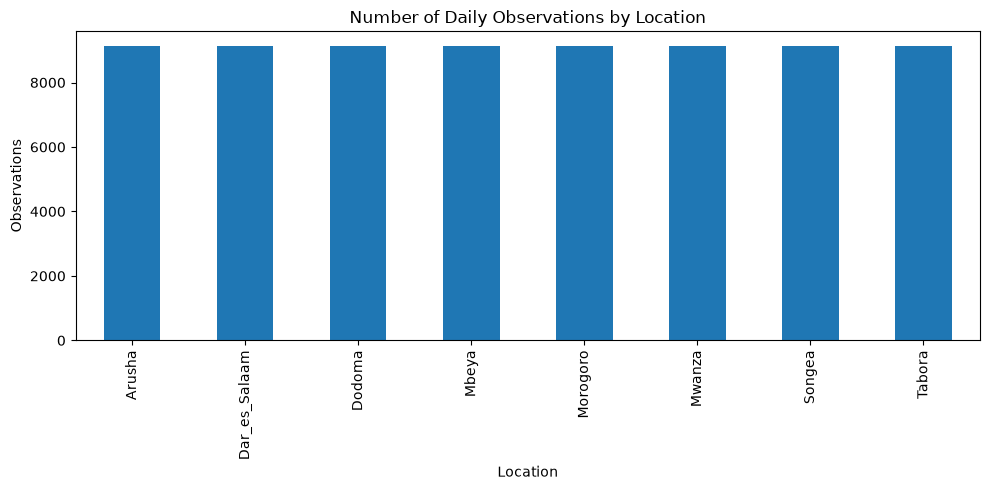

In [62]:
location_counts = profile_df.groupby('location').size().sort_values(ascending=False)
display(location_counts)

location_counts.plot(kind='bar', figsize=(10, 5))
plt.title('Number of Daily Observations by Location')
plt.xlabel('Location')
plt.ylabel('Observations')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'observations_by_location.png', dpi=200)
plt.show()


## 19. Assess Annual Record Completeness

**Purpose:** Count observations by location and year and visualize annual availability to reveal incomplete years or temporal gaps.


location,Arusha,Dar_es_Salaam,Dodoma,Mbeya,Morogoro,Mwanza,Songea,Tabora
year,,,,,,,,
2021,365,365,365,365,365,365,365,365
2022,365,365,365,365,365,365,365,365
2023,365,365,365,365,365,365,365,365
2024,366,366,366,366,366,366,366,366
2025,365,365,365,365,365,365,365,365


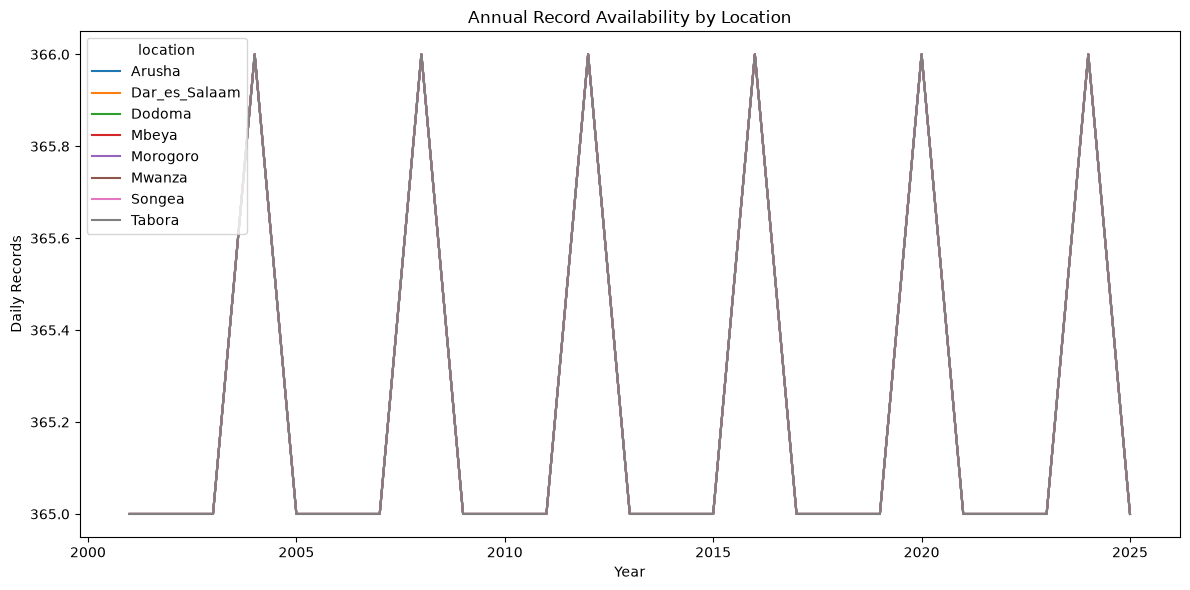

In [63]:
profile_df['year'] = profile_df['date'].dt.year

annual_counts = (
    profile_df.groupby(['location', 'year']).size().unstack(0)
)
display(annual_counts.tail())

annual_counts.plot(figsize=(12, 6))
plt.title('Annual Record Availability by Location')
plt.xlabel('Year')
plt.ylabel('Daily Records')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'annual_record_availability.png', dpi=200)
plt.show()


## 20. Explore Temperature and Precipitation Distributions

**Purpose:** Plot basic distributions for mean daily temperature and precipitation to identify skewness, unusual ranges, and candidate anomalies.


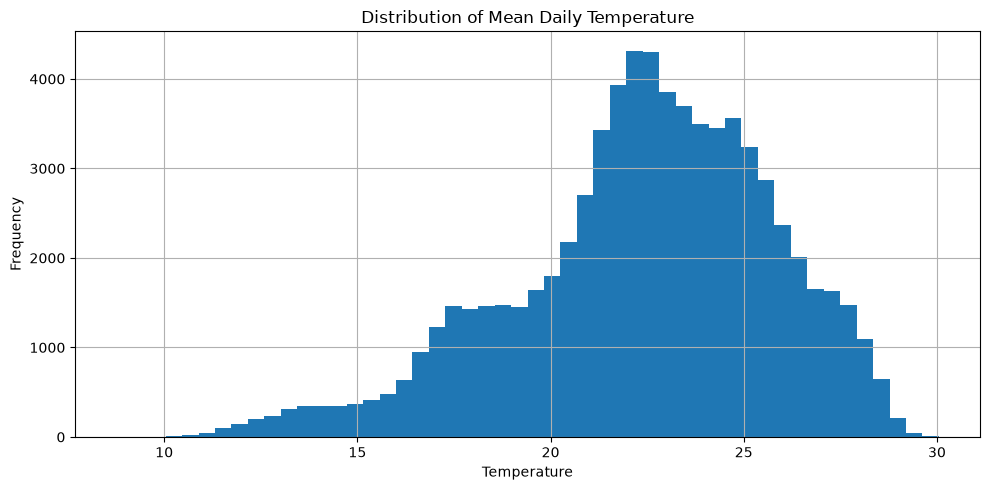

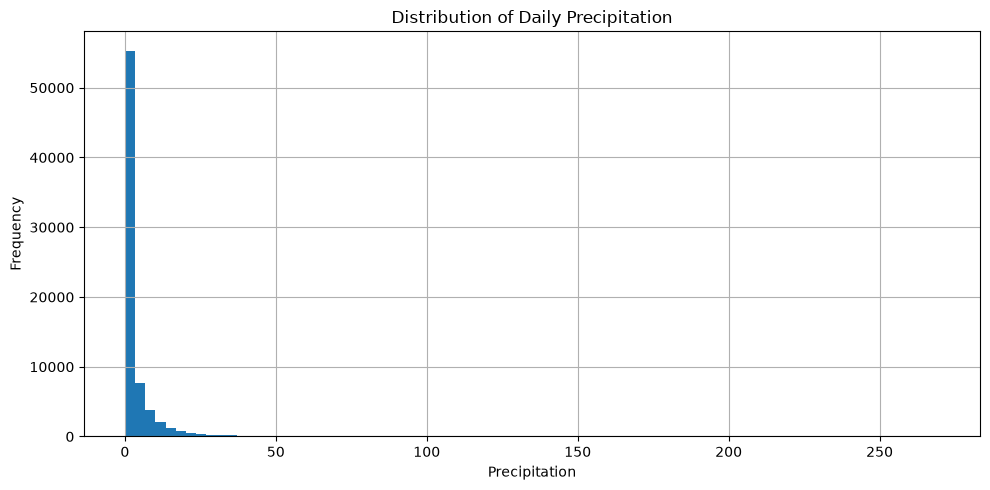

In [64]:
profile_df['T2M'].hist(bins=50, figsize=(10, 5))
plt.title('Distribution of Mean Daily Temperature')
plt.xlabel('Temperature')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

profile_df['PRECTOTCORR'].hist(bins=80, figsize=(10, 5))
plt.title('Distribution of Daily Precipitation')
plt.xlabel('Precipitation')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## 21. Screen for Statistical Outliers Using the IQR Method

**Purpose:** Use the interquartile range as a diagnostic flag for unusual values. These observations are not automatically treated as errors or removed.


In [65]:
def iqr_outlier_summary(series):
    clean = series.dropna()
    if clean.empty:
        return {
            'q1': None,
            'q3': None,
            'iqr': None,
            'lower_bound': None,
            'upper_bound': None,
            'outlier_count': 0,
            'outlier_percent': 0.0,
        }

    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - (1.5 * iqr)
    upper = q3 + (1.5 * iqr)
    outliers = clean[(clean < lower) | (clean > upper)]

    return {
        'q1': float(q1),
        'q3': float(q3),
        'iqr': float(iqr),
        'lower_bound': float(lower),
        'upper_bound': float(upper),
        'outlier_count': int(len(outliers)),
        'outlier_percent': float(len(outliers) / len(clean) * 100),
    }

outlier_summary = {col: iqr_outlier_summary(profile_df[col]) for col in meteo_columns}
display(pd.DataFrame(outlier_summary).T)


,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percent
T2M,20.550,24.830,4.280,14.130,31.250,"1,636.000",2.240
T2M_MIN,15.010,20.080,5.070,7.405,27.685,"1,037.000",1.420
T2M_MAX,25.940,30.310,4.370,19.385,36.865,344.000,0.471
RH2M,61.930,81.370,19.440,32.770,110.530,109.000,0.149
PRECTOTCORR,0.030,3.230,3.200,-4.770,8.030,"8,350.000",11.431
WS2M,1.590,3.530,1.940,-1.320,6.440,156.000,0.214
ALLSKY_SFC_SW_DWN,17.770,23.620,5.850,8.995,32.395,897.000,1.228


## 22. Build and Save the Data Quality Report

**Purpose:** Combine key profiling statistics and validation results into a machine-readable JSON report for reproducibility and later pipeline stages.


In [66]:
quality_summary = {
    'dataset': {
        'rows': int(profile_df.shape[0]),
        'columns': int(profile_df.shape[1]),
        'locations': int(profile_df['location'].nunique()),
        'start_date': str(profile_df['date'].min()),
        'end_date': str(profile_df['date'].max()),
    },
    'quality_checks': {
        'invalid_dates': int(profile_df['date'].isna().sum()),
        'exact_duplicate_rows': int(profile_df.duplicated().sum()),
        'duplicate_location_date_rows': int(
            profile_df.duplicated(subset=['location', 'date'], keep=False).sum()
        ),
        'temperature_consistency_violations': int(len(invalid_temp_order)),
        'invalid_relative_humidity': int(len(invalid_humidity)),
        'negative_precipitation': int(len(negative_precipitation)),
        'negative_wind_speed': int(len(negative_wind)),
        'negative_solar_radiation': int(len(negative_solar)),
        'invalid_coordinates': int(len(invalid_coordinates)),
    },
    'missing_values': {
        column: int(value)
        for column, value in profile_df[meteo_columns].isna().sum().items()
    },
    'sentinel_values': sentinel_results,
    'missing_days_by_location': {
        location: len(dates)
        for location, dates in missing_dates_by_location.items()
    },
}

REPORT_PATH = REPORT_DIR / 'initial_data_quality_report.json'
with open(REPORT_PATH, 'w', encoding='utf-8') as file:
    json.dump(quality_summary, file, indent=4)

print(f'Report saved to: {REPORT_PATH}')


Report saved to: d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\reports\initial_data_quality_report.json


## 23. Create the Candidate Data Quality Problems Table

**Purpose:** Translate diagnostic results into named data-quality dimensions such as completeness, uniqueness, consistency, and validity, then save them as CSV.


In [67]:
problems = [
    {
        'dimension': 'Completeness',
        'problem': 'Missing daily dates',
        'count': int(sum(len(v) for v in missing_dates_by_location.values())),
    },
    {
        'dimension': 'Uniqueness',
        'problem': 'Duplicate location-date records',
        'count': int(
            profile_df.duplicated(subset=['location', 'date'], keep=False).sum()
        ),
    },
    {
        'dimension': 'Consistency',
        'problem': 'Invalid min/mean/max temperature ordering',
        'count': int(len(invalid_temp_order)),
    },
    {
        'dimension': 'Validity',
        'problem': 'Relative humidity outside 0–100%',
        'count': int(len(invalid_humidity)),
    },
    {
        'dimension': 'Validity',
        'problem': 'Negative precipitation values',
        'count': int(len(negative_precipitation)),
    },
    {
        'dimension': 'Validity',
        'problem': 'Negative wind-speed values',
        'count': int(len(negative_wind)),
    },
]

problem_df = pd.DataFrame(problems)
display(problem_df)

problem_path = REPORT_DIR / 'candidate_data_quality_problems.csv'
problem_df.to_csv(problem_path, index=False)
print(f'Candidate problems saved to: {problem_path}')


,dimension,problem,count
0,Completeness,Missing daily dates,0
1,Uniqueness,Duplicate location-date records,0
2,Consistency,Invalid min/mean/max temperature ordering,0
3,Validity,Relative humidity outside 0–100%,0
4,Validity,Negative precipitation values,0
5,Validity,Negative wind-speed values,0


Candidate problems saved to: d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\reports\candidate_data_quality_problems.csv


## 24. Display the Final Profiling Summary

**Purpose:** Print the most important profiling results and generated output files so the reviewer can quickly understand the overall dataset quality status.


In [68]:
print('=' * 60)
print('HYDROMET DATA QUALITY PROFILING SUMMARY')
print('=' * 60)
print(f"Records: {len(profile_df):,}")
print(f"Locations: {profile_df['location'].nunique()}")
print(f"Period: {profile_df['date'].min().date()} to {profile_df['date'].max().date()}")
print(f"Exact duplicates: {profile_df.duplicated().sum():,}")
print('Duplicate location-date rows:', profile_df.duplicated(subset=['location', 'date'], keep=False).sum())
print('Missing daily dates:', sum(len(v) for v in missing_dates_by_location.values()))
print('Temperature consistency violations:', len(invalid_temp_order))
print('Invalid RH values:', len(invalid_humidity))
print('Negative precipitation:', len(negative_precipitation))
print('Negative wind speed:', len(negative_wind))
print('Negative solar radiation:', len(negative_solar))
print('Invalid coordinates:', len(invalid_coordinates))

print('\nGenerated files:')
print('-', REPORT_PATH)
print('-', problem_path)
print('-', FIGURE_DIR / 'observations_by_location.png')
print('-', FIGURE_DIR / 'annual_record_availability.png')

print('\nProfiling complete. No cleaning has been applied.')


HYDROMET DATA QUALITY PROFILING SUMMARY
Records: 73,048
Locations: 8
Period: 2001-01-01 to 2025-12-31
Exact duplicates: 0
Duplicate location-date rows: 0
Missing daily dates: 0
Temperature consistency violations: 0
Invalid RH values: 0
Negative precipitation: 0
Negative wind speed: 0
Negative solar radiation: 0
Invalid coordinates: 0

Generated files:
- d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\reports\initial_data_quality_report.json
- d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\reports\candidate_data_quality_problems.csv
- d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\figures\observations_by_location.png
- d:\NMAIST_MASTERS LIFE\Semister 2 Courses\DATA ENGINEERING AND ANALYTICS\Projects\hydromet-data-pipeline\outputs\figures\annual_record_availability.png

Profiling complete. No c